In [2]:
# Run this cell first in Google Colab
!pip install -q nltk wordcloud vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.6 MB/s eta 0:00:00


In [3]:
import re
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from collections import Counter
from wordcloud import WordCloud
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

import nltk
from nltk.corpus import stopwords
from nltk.util import ngrams

warnings.filterwarnings("ignore")

nltk.download("stopwords")
nltk.download("punkt")
nltk.download("punkt_tab")

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [4]:
from google.colab import files

uploaded = files.upload()

Saving Womens Clothing E-Commerce Reviews.csv to Womens Clothing E-Commerce Reviews.csv


In [5]:
import re
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from collections import Counter
from wordcloud import WordCloud
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

import nltk
from nltk.corpus import stopwords
from nltk.util import ngrams

warnings.filterwarnings("ignore")

nltk.download("stopwords")
nltk.download("punkt")
nltk.download("punkt_tab")

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [6]:
file_name = "Womens Clothing E-Commerce Reviews.csv"

df = pd.read_csv(file_name)

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (23486, 11)


,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [7]:
print("Column names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("Data Type"))

print("\nMissing values:")
display(
    df.isnull()
      .sum()
      .sort_values(ascending=False)
      .to_frame("Missing Values")
)

print("\nDuplicate rows:", df.duplicated().sum())

Column names:
['Unnamed: 0', 'Clothing ID', 'Age', 'Title', 'Review Text', 'Rating', 'Recommended IND', 'Positive Feedback Count', 'Division Name', 'Department Name', 'Class Name']

Data types:


,Data Type
Unnamed: 0,int64
Clothing ID,int64
Age,int64
Title,object
Review Text,object
Rating,int64
Recommended IND,int64
Positive Feedback Count,int64
Division Name,object
Department Name,object



Missing values:


,Missing Values
Title,3810
Review Text,845
Department Name,14
Class Name,14
Division Name,14
Unnamed: 0,0
Clothing ID,0
Age,0
Rating,0
Recommended IND,0



Duplicate rows: 0


In [8]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,23486.0,11742.500000,6779.968547,0.0,5871.25,11742.5,17613.75,23485.0
Clothing ID,23486.0,918.118709,203.298980,0.0,861.00,936.0,1078.00,1205.0
Age,23486.0,43.198544,12.279544,18.0,34.00,41.0,52.00,99.0
Rating,23486.0,4.196032,1.110031,1.0,4.00,5.0,5.00,5.0
Recommended IND,23486.0,0.822362,0.382216,0.0,1.00,1.0,1.00,1.0
Positive Feedback Count,23486.0,2.535936,5.702202,0.0,0.00,1.0,3.00,122.0


In [9]:
categorical_columns = [
    "Division Name",
    "Department Name",
    "Class Name"
]

for column in categorical_columns:
    print(f"\nValue counts for {column}:")
    display(df[column].value_counts(dropna=False).head(15))


Value counts for Division Name:


,count
Division Name,
General,13850
General Petite,8120
Initmates,1502
NaN,14



Value counts for Department Name:


,count
Department Name,
Tops,10468
Dresses,6319
Bottoms,3799
Intimate,1735
Jackets,1032
Trend,119
NaN,14



Value counts for Class Name:


,count
Class Name,
Dresses,6319
Knits,4843
Blouses,3097
Sweaters,1428
Pants,1388
Jeans,1147
Fine gauge,1100
Skirts,945
Jackets,704


In [10]:
df = df.drop(columns=["Unnamed: 0"], errors="ignore")

# Remove duplicate rows
df = df.drop_duplicates().copy()

# A review without text cannot be used for NLP analysis
df = df.dropna(subset=["Review Text"]).copy()

# Replace missing titles
df["Title"] = df["Title"].fillna("No Title")

# Replace missing category values
category_columns = [
    "Division Name",
    "Department Name",
    "Class Name"
]

for column in category_columns:
    df[column] = df[column].fillna("Unknown")

# Remove extra spaces from text
df["Review Text"] = (
    df["Review Text"]
      .astype(str)
      .str.strip()
)

df["Title"] = (
    df["Title"]
      .astype(str)
      .str.strip()
)

# Remove blank reviews, if present
df = df[df["Review Text"].str.len() > 0].copy()

df.reset_index(drop=True, inplace=True)

print("Cleaned dataset shape:", df.shape)
display(df.head())

Cleaned dataset shape: (22640, 10)


,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,767,33,No Title,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1080,34,No Title,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [11]:
df["Review Length"] = df["Review Text"].str.split().str.len()

df["Recommendation Label"] = df["Recommended IND"].map({
    1: "Recommended",
    0: "Not Recommended"
})

# Rating-based sentiment is useful as a business label:
# 1–2 = Negative, 3 = Neutral, 4–5 = Positive
df["Rating Sentiment"] = np.select(
    [
        df["Rating"].isin([1, 2]),
        df["Rating"].eq(3),
        df["Rating"].isin([4, 5])
    ],
    [
        "Negative",
        "Neutral",
        "Positive"
    ],
    default="Unknown"
)

display(df[
    [
        "Review Text",
        "Review Length",
        "Rating",
        "Rating Sentiment",
        "Recommendation Label"
    ]
].head())

,Review Text,Review Length,Rating,Rating Sentiment,Recommendation Label
0,Absolutely wonderful - silky and sexy and comf...,8,4,Positive,Recommended
1,Love this dress! it's sooo pretty. i happene...,62,5,Positive,Recommended
2,I had such high hopes for this dress and reall...,98,3,Neutral,Not Recommended
3,"I love, love, love this jumpsuit. it's fun, fl...",22,5,Positive,Recommended
4,This shirt is very flattering to all due to th...,36,5,Positive,Recommended


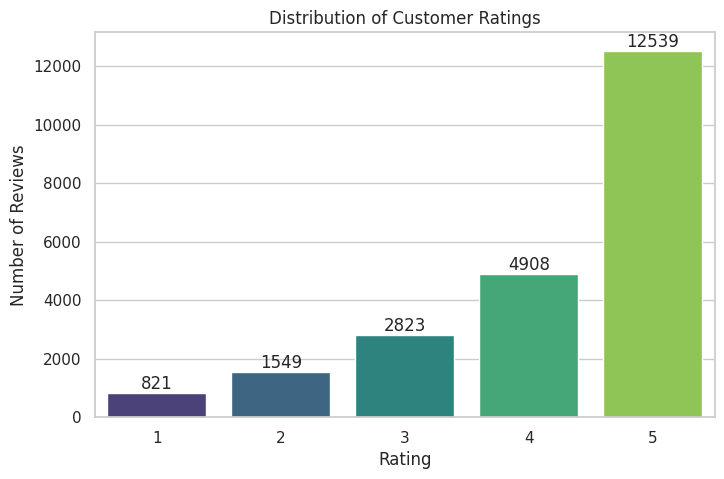

In [12]:
plt.figure(figsize=(8, 5))

rating_order = sorted(df["Rating"].unique())

ax = sns.countplot(
    data=df,
    x="Rating",
    order=rating_order,
    palette="viridis"
)

plt.title("Distribution of Customer Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

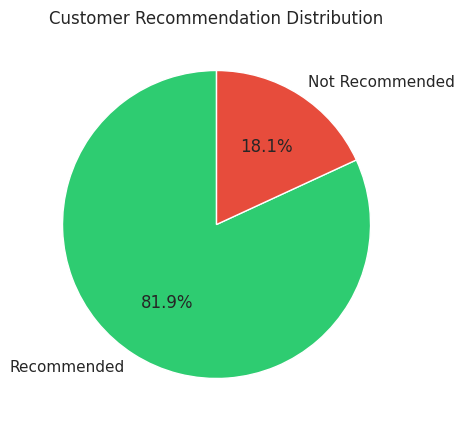

In [13]:
recommendation_counts = (
    df["Recommendation Label"]
    .value_counts()
)

plt.figure(figsize=(7, 5))

plt.pie(
    recommendation_counts.values,
    labels=recommendation_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["#2ecc71", "#e74c3c"]
)

plt.title("Customer Recommendation Distribution")
plt.show()

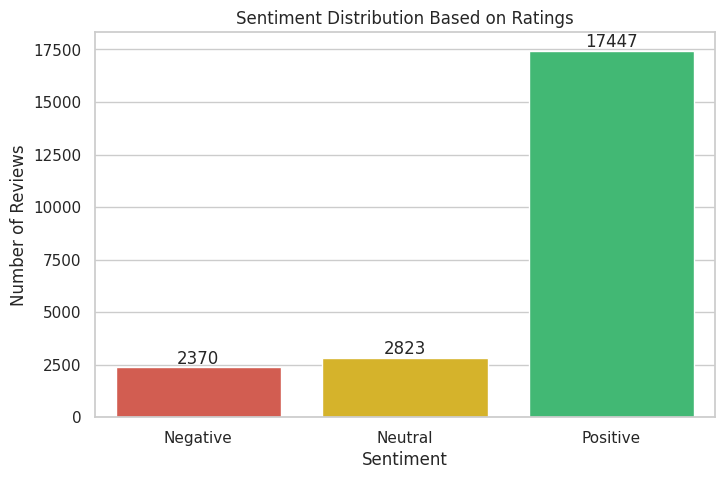

In [14]:
sentiment_order = ["Negative", "Neutral", "Positive"]

plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x="Rating Sentiment",
    order=sentiment_order,
    palette={
        "Negative": "#e74c3c",
        "Neutral": "#f1c40f",
        "Positive": "#2ecc71"
    }
)

plt.title("Sentiment Distribution Based on Ratings")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

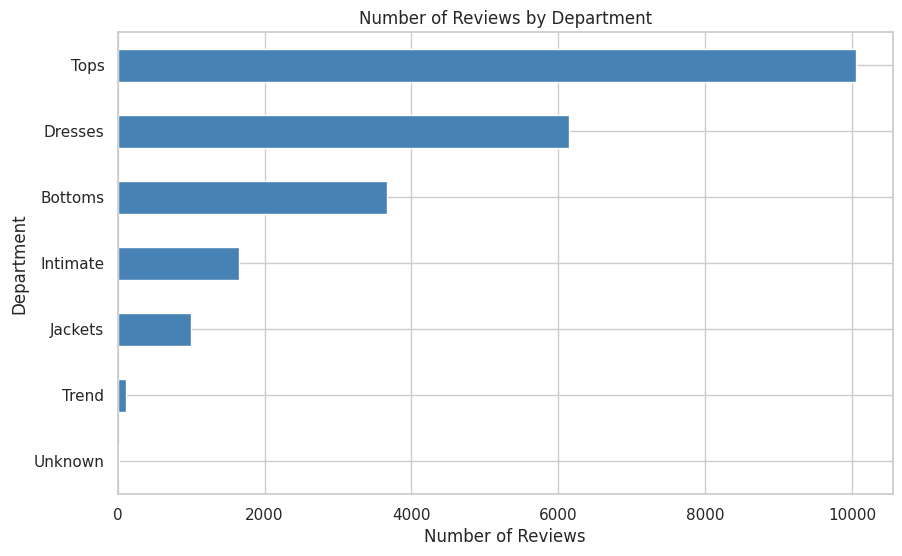

In [15]:
department_reviews = (
    df["Department Name"]
    .value_counts()
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 6))

department_reviews.plot(
    kind="barh",
    color="steelblue"
)

plt.title("Number of Reviews by Department")
plt.xlabel("Number of Reviews")
plt.ylabel("Department")
plt.show()

In [16]:
department_rating = (
    df.groupby("Department Name")
      .agg(
          Review_Count=("Rating", "size"),
          Average_Rating=("Rating", "mean"),
          Recommendation_Rate=("Recommended IND", "mean")
      )
      .sort_values("Average_Rating")
      .reset_index()
)

department_rating["Recommendation_Rate"] *= 100

display(department_rating.round(2))

,Department Name,Review_Count,Average_Rating,Recommendation_Rate
0,Trend,118,3.84,74.58
1,Dresses,6145,4.14,80.52
2,Tops,10048,4.16,81.07
3,Jackets,1002,4.25,83.33
4,Intimate,1653,4.27,84.63
5,Bottoms,3661,4.28,84.95
6,Unknown,13,5.00,100.00


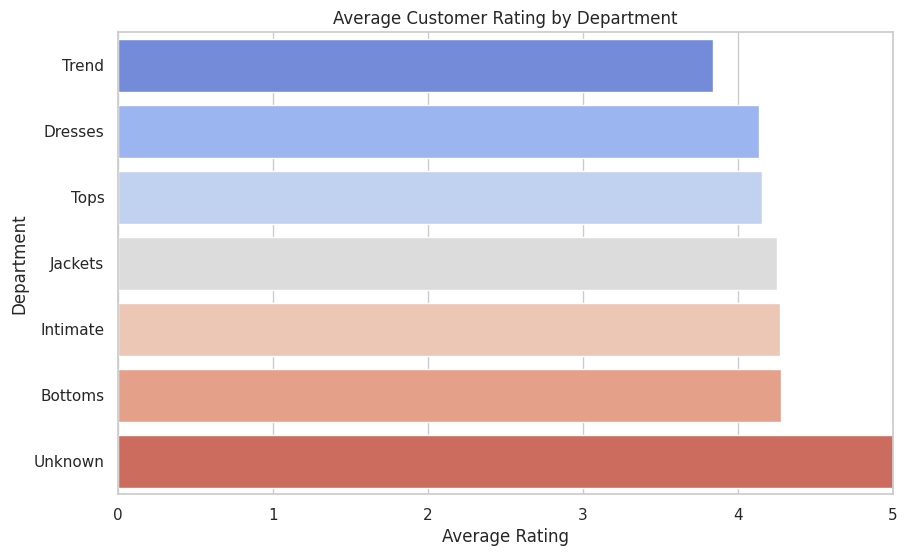

In [17]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=department_rating,
    x="Average_Rating",
    y="Department Name",
    palette="coolwarm"
)

plt.title("Average Customer Rating by Department")
plt.xlabel("Average Rating")
plt.ylabel("Department")
plt.xlim(0, 5)
plt.show()

In [18]:
stop_words = set(stopwords.words("english"))

negation_words = {
    "no",
    "not",
    "nor",
    "never",
    "too",
    "very"
}

stop_words = stop_words - negation_words

def clean_review(text):
    text = str(text).lower()

    # Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)

    # Keep only letters and apostrophes
    text = re.sub(r"[^a-z']", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    tokens = [
        word for word in text.split()
        if word not in stop_words and len(word) > 2
    ]

    return " ".join(tokens)

df["Clean Review"] = df["Review Text"].apply(clean_review)

display(df[["Review Text", "Clean Review"]].head())

,Review Text,Clean Review
0,Absolutely wonderful - silky and sexy and comf...,absolutely wonderful silky sexy comfortable
1,Love this dress! it's sooo pretty. i happene...,love dress sooo pretty happened find store gla...
2,I had such high hopes for this dress and reall...,high hopes dress really wanted work initially ...
3,"I love, love, love this jumpsuit. it's fun, fl...",love love love jumpsuit fun flirty fabulous ev...
4,This shirt is very flattering to all due to th...,shirt very flattering due adjustable front tie...


In [19]:
sentiment_analyzer = SentimentIntensityAnalyzer()

sentiment_scores = df["Review Text"].apply(
    sentiment_analyzer.polarity_scores
)

df["Negative Score"] = sentiment_scores.apply(
    lambda score: score["neg"]
)

df["Neutral Score"] = sentiment_scores.apply(
    lambda score: score["neu"]
)

df["Positive Score"] = sentiment_scores.apply(
    lambda score: score["pos"]
)

df["Compound Score"] = sentiment_scores.apply(
    lambda score: score["compound"]
)

def assign_vader_sentiment(score):
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

df["VADER Sentiment"] = df["Compound Score"].apply(
    assign_vader_sentiment
)

display(df[
    [
        "Review Text",
        "Rating",
        "Compound Score",
        "VADER Sentiment"
    ]
].head(10))

,Review Text,Rating,Compound Score,VADER Sentiment
0,Absolutely wonderful - silky and sexy and comf...,4,0.8932,Positive
1,Love this dress! it's sooo pretty. i happene...,5,0.9729,Positive
2,I had such high hopes for this dress and reall...,3,0.9208,Positive
3,"I love, love, love this jumpsuit. it's fun, fl...",5,0.5727,Positive
4,This shirt is very flattering to all due to th...,5,0.9291,Positive
5,"I love tracy reese dresses, but this one is no...",2,0.9419,Positive
6,I aded this in my basket at hte last mintue to...,5,0.6779,Positive
7,"I ordered this in carbon for store pick up, an...",4,-0.0909,Negative
8,I love this dress. i usually get an xs but it ...,5,0.7175,Positive
9,"I'm 5""5' and 125 lbs. i ordered the s petite t...",5,0.8689,Positive


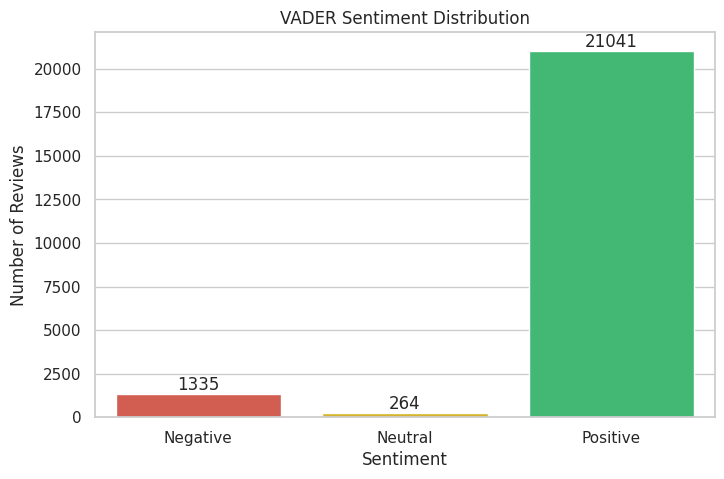

,Percentage
VADER Sentiment,
Negative,5.90
Neutral,1.17
Positive,92.94


In [20]:
vader_counts = (
    df["VADER Sentiment"]
    .value_counts()
    .reindex(["Negative", "Neutral", "Positive"])
    .fillna(0)
)

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=vader_counts.index,
    y=vader_counts.values,
    palette={
        "Negative": "#e74c3c",
        "Neutral": "#f1c40f",
        "Positive": "#2ecc71"
    }
)

plt.title("VADER Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

display(
    (vader_counts / vader_counts.sum() * 100)
    .round(2)
    .to_frame("Percentage")
)

In [21]:
sentiment_rating_table = pd.crosstab(
    df["Rating"],
    df["VADER Sentiment"],
    normalize="index"
) * 100

display(sentiment_rating_table.round(2))

VADER Sentiment,Negative,Neutral,Positive
Rating,,,
1,34.59,3.29,62.12
2,21.76,3.49,74.76
3,13.14,2.94,83.92
4,4.01,1.18,94.80
5,1.16,0.33,98.50


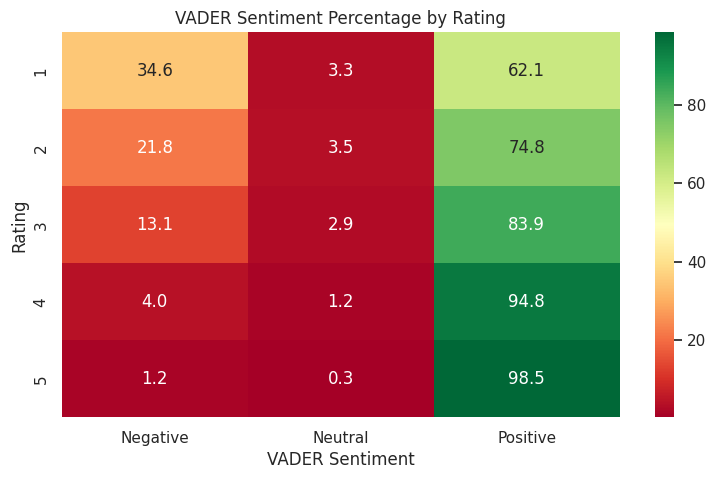

In [22]:
plt.figure(figsize=(9, 5))

sns.heatmap(
    sentiment_rating_table,
    annot=True,
    fmt=".1f",
    cmap="RdYlGn"
)

plt.title("VADER Sentiment Percentage by Rating")
plt.xlabel("VADER Sentiment")
plt.ylabel("Rating")
plt.show()

In [23]:
df["Sentiment Agreement"] = (
    df["Rating Sentiment"] == df["VADER Sentiment"]
)

agreement_percentage = df["Sentiment Agreement"].mean() * 100

print(
    "Agreement between rating sentiment and VADER sentiment:",
    round(agreement_percentage, 2),
    "%"
)

Agreement between rating sentiment and VADER sentiment: 78.22 %


In [24]:
negative_reviews = df[
    (df["Rating"] <= 2) |
    (df["Recommended IND"] == 0) |
    (df["VADER Sentiment"] == "Negative")
].copy()

print("Number of issue-related reviews:", len(negative_reviews))

display(
    negative_reviews[
        [
            "Clothing ID",
            "Department Name",
            "Class Name",
            "Rating",
            "Review Text"
        ]
    ].head()
)

Number of issue-related reviews: 4629


,Clothing ID,Department Name,Class Name,Rating,Review Text
2,1077,Dresses,Dresses,3,I had such high hopes for this dress and reall...
5,1080,Dresses,Dresses,2,"I love tracy reese dresses, but this one is no..."
7,858,Tops,Knits,4,"I ordered this in carbon for store pick up, an..."
10,1077,Dresses,Dresses,3,Dress runs small esp where the zipper area run...
14,1077,Dresses,Dresses,3,This is a nice choice for holiday gatherings. ...


In [25]:
issue_dictionary = {
    "Size Runs Small": [
        r"\btoo small\b",
        r"\bruns small\b",
        r"\btight\b",
        r"\bsmaller than\b",
        r"\bcould not zip\b",
        r"\bcan't zip\b"
    ],

    "Size Runs Large": [
        r"\btoo large\b",
        r"\btoo big\b",
        r"\bruns large\b",
        r"\boversized\b",
        r"\bbaggy\b",
        r"\bloose\b"
    ],

    "Poor Fit": [
        r"\bpoor fit\b",
        r"\bdid not fit\b",
        r"\bdoesn't fit\b",
        r"\bnot fit\b",
        r"\bfit weird\b",
        r"\bawkward fit\b",
        r"\bunflattering\b"
    ],

    "Poor Quality": [
        r"\bpoor quality\b",
        r"\bcheap\b",
        r"\bflimsy\b",
        r"\bthin material\b",
        r"\bsee through\b",
        r"\bsee-through\b",
        r"\btransparent\b",
        r"\bnot worth\b"
    ],

    "Fabric or Material": [
        r"\bfabric\b",
        r"\bmaterial\b",
        r"\bscratchy\b",
        r"\bitchy\b",
        r"\bstiff\b",
        r"\buncomfortable\b",
        r"\bwrinkle\b"
    ],

    "Color Mismatch": [
        r"\bcolor\b",
        r"\bcolour\b",
        r"\bfaded\b",
        r"\bdifferent color\b",
        r"\bnot as pictured\b",
        r"\bnot as shown\b"
    ],

    "Length Issue": [
        r"\btoo long\b",
        r"\btoo short\b",
        r"\blength\b",
        r"\bpetite\b",
        r"\bhem\b"
    ],

    "Design Problem": [
        r"\bdesign flaw\b",
        r"\bpoor design\b",
        r"\bawkward\b",
        r"\bweird\b",
        r"\bstrange\b",
        r"\bcut\b"
    ],

    "Damaged or Defective": [
        r"\bdamaged\b",
        r"\bdefective\b",
        r"\bbroken\b",
        r"\bripped\b",
        r"\btorn\b",
        r"\bhole\b",
        r"\bfrayed\b",
        r"\bstain\b"
    ],

    "Stitching or Seam": [
        r"\bstitch\b",
        r"\bstitching\b",
        r"\bseam\b",
        r"\bsewing\b",
        r"\bthread\b",
        r"\bzipper\b",
        r"\bbutton\b"
    ],

    "Shrinkage": [
        r"\bshrink\b",
        r"\bshrunk\b",
        r"\bshrunken\b",
        r"\bafter washing\b",
        r"\bafter wash\b"
    ]
}

In [26]:
def identify_issues(text):
    text = str(text).lower()
    found_issues = []

    for issue, patterns in issue_dictionary.items():
        if any(re.search(pattern, text) for pattern in patterns):
            found_issues.append(issue)

    if not found_issues:
        found_issues.append("Other/Unclassified")

    return found_issues

negative_reviews["Reported Issues"] = (
    negative_reviews["Review Text"]
    .apply(identify_issues)
)

display(
    negative_reviews[
        [
            "Review Text",
            "Reported Issues"
        ]
    ].head(10)
)

,Review Text,Reported Issues
2,I had such high hopes for this dress and reall...,"[Size Runs Small, Poor Quality, Length Issue, ..."
5,"I love tracy reese dresses, but this one is no...","[Color Mismatch, Length Issue]"
7,"I ordered this in carbon for store pick up, an...","[Size Runs Large, Color Mismatch, Length Issue]"
10,Dress runs small esp where the zipper area run...,"[Size Runs Small, Poor Quality, Fabric or Mate..."
14,This is a nice choice for holiday gatherings. ...,"[Size Runs Small, Size Runs Large, Fabric or M..."
22,"First of all, this is not pullover styling. th...","[Size Runs Small, Poor Quality, Design Problem..."
25,"Loved the material, but i didnt really look at...",[Fabric or Material]
26,I have been waiting for this sweater coat to s...,[Other/Unclassified]
33,"I ordered this 3 months ago, and it finally ca...","[Poor Quality, Fabric or Material]"
56,I am pregnant and i thought this would be a gr...,[Other/Unclassified]


In [27]:
issue_counts = (
    negative_reviews["Reported Issues"]
    .explode()
    .value_counts()
    .rename_axis("Issue")
    .reset_index(name="Frequency")
)

issue_counts["Percentage of Issue Reviews"] = (
    issue_counts["Frequency"] /
    len(negative_reviews) * 100
)

display(issue_counts.round(2))

,Issue,Frequency,Percentage of Issue Reviews
0,Fabric or Material,1871,40.42
1,Other/Unclassified,988,21.34
2,Length Issue,791,17.09
3,Color Mismatch,758,16.38
4,Design Problem,683,14.75
5,Size Runs Large,588,12.70
6,Size Runs Small,511,11.04
7,Poor Quality,476,10.28
8,Stitching or Seam,343,7.41
9,Poor Fit,304,6.57


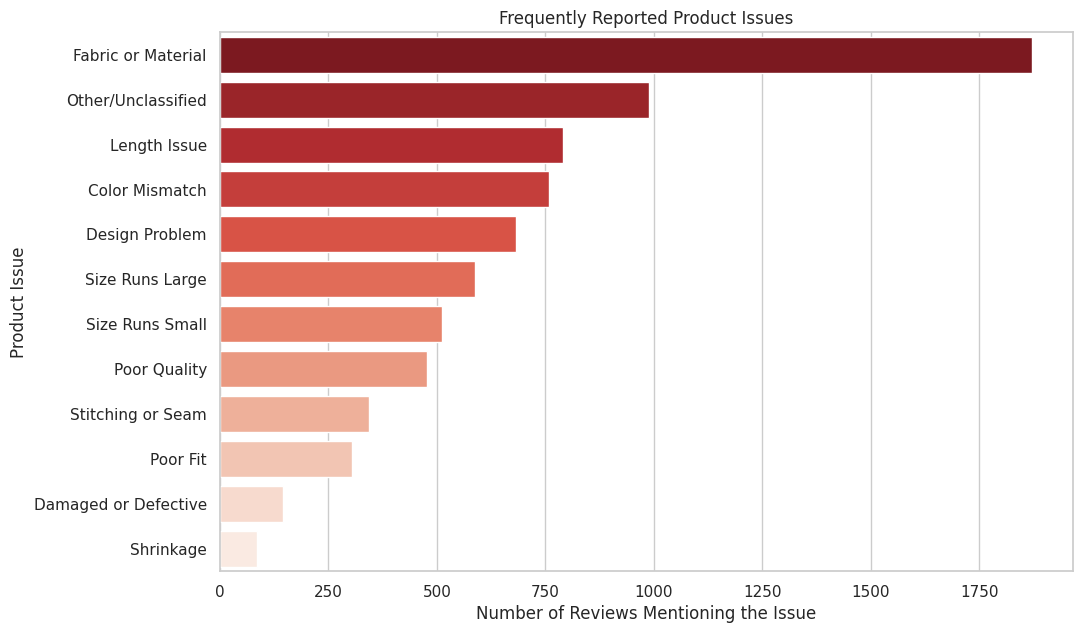

In [28]:
plt.figure(figsize=(11, 7))

sns.barplot(
    data=issue_counts,
    x="Frequency",
    y="Issue",
    palette="Reds_r"
)

plt.title("Frequently Reported Product Issues")
plt.xlabel("Number of Reviews Mentioning the Issue")
plt.ylabel("Product Issue")
plt.show()

In [29]:
department_issue_table = (
    negative_reviews[
        ["Department Name", "Reported Issues"]
    ]
    .explode("Reported Issues")
    .groupby(
        ["Department Name", "Reported Issues"]
    )
    .size()
    .reset_index(name="Issue Count")
)

display(
    department_issue_table
    .sort_values("Issue Count", ascending=False)
    .head(20)
)

,Department Name,Reported Issues,Issue Count
51,Tops,Fabric or Material,826
15,Dresses,Fabric or Material,615
53,Tops,Other/Unclassified,464
48,Tops,Color Mismatch,369
52,Tops,Length Issue,328
50,Tops,Design Problem,318
57,Tops,Size Runs Large,272
16,Dresses,Length Issue,270
17,Dresses,Other/Unclassified,268
3,Bottoms,Fabric or Material,250


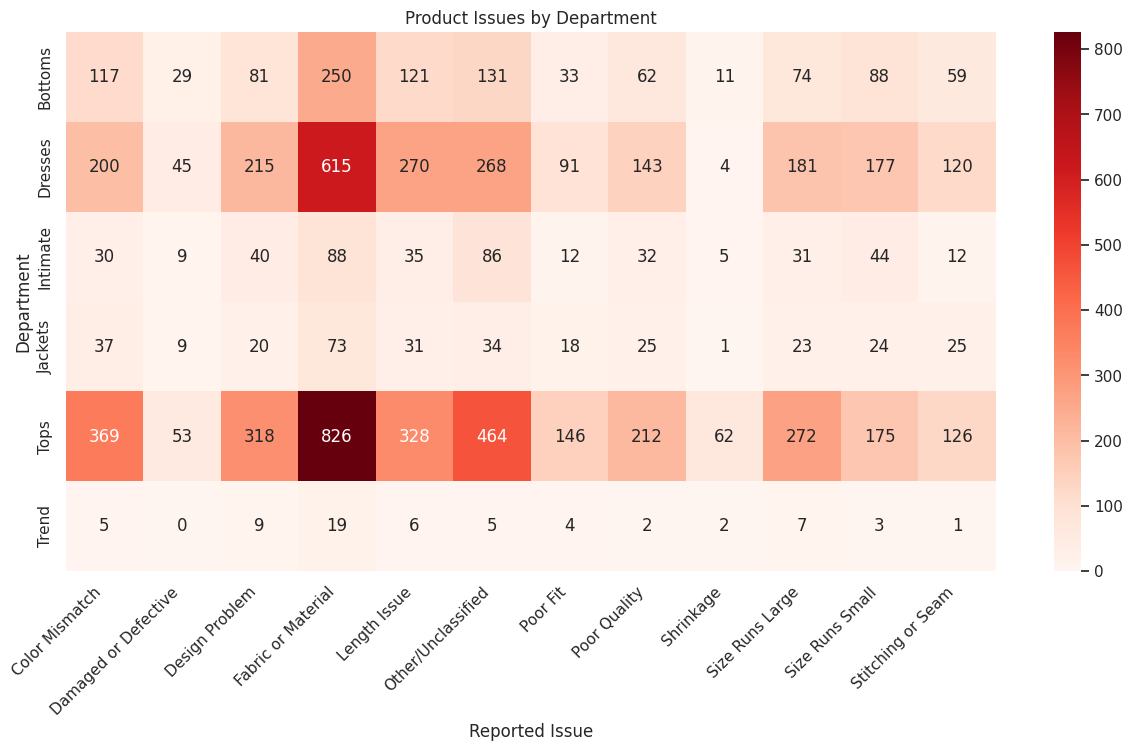

In [30]:
department_issue_pivot = department_issue_table.pivot_table(
    index="Department Name",
    columns="Reported Issues",
    values="Issue Count",
    fill_value=0
)

plt.figure(figsize=(15, 7))

sns.heatmap(
    department_issue_pivot,
    annot=True,
    fmt=".0f",
    cmap="Reds"
)

plt.title("Product Issues by Department")
plt.xlabel("Reported Issue")
plt.ylabel("Department")
plt.xticks(rotation=45, ha="right")
plt.show()

In [31]:
negative_words = " ".join(
    negative_reviews["Clean Review"].dropna()
).split()

word_frequency = pd.DataFrame(
    Counter(negative_words).most_common(25),
    columns=["Word", "Frequency"]
)

display(word_frequency)

,Word,Frequency
0,not,2856
1,dress,2260
2,like,1930
3,very,1740
4,top,1672
5,too,1631
6,size,1480
7,would,1450
8,fit,1444
9,fabric,1359


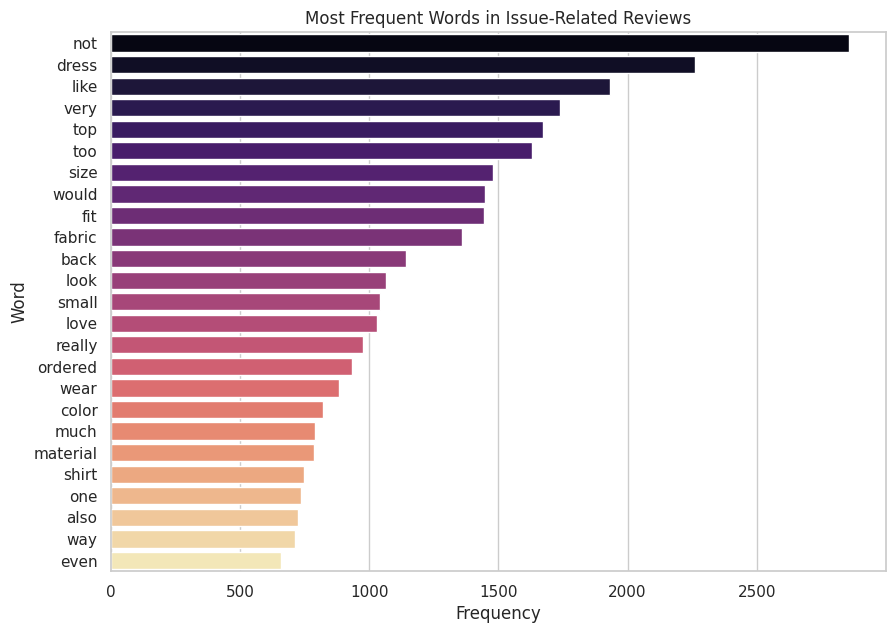

In [32]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=word_frequency,
    x="Frequency",
    y="Word",
    palette="magma"
)

plt.title("Most Frequent Words in Issue-Related Reviews")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.show()

In [33]:
all_negative_tokens = []

for review in negative_reviews["Clean Review"].dropna():
    all_negative_tokens.extend(review.split())

bigram_counts = Counter(
    ngrams(all_negative_tokens, 2)
)

top_bigrams = pd.DataFrame(
    [
        (" ".join(words), frequency)
        for words, frequency in bigram_counts.most_common(25)
    ],
    columns=["Phrase", "Frequency"]
)

display(top_bigrams)

,Phrase,Frequency
0,wanted love,246
1,going back,229
2,way too,228
3,too much,223
4,not flattering,199
5,looked like,197
6,too big,183
7,really wanted,163
8,looks like,160
9,too short,147


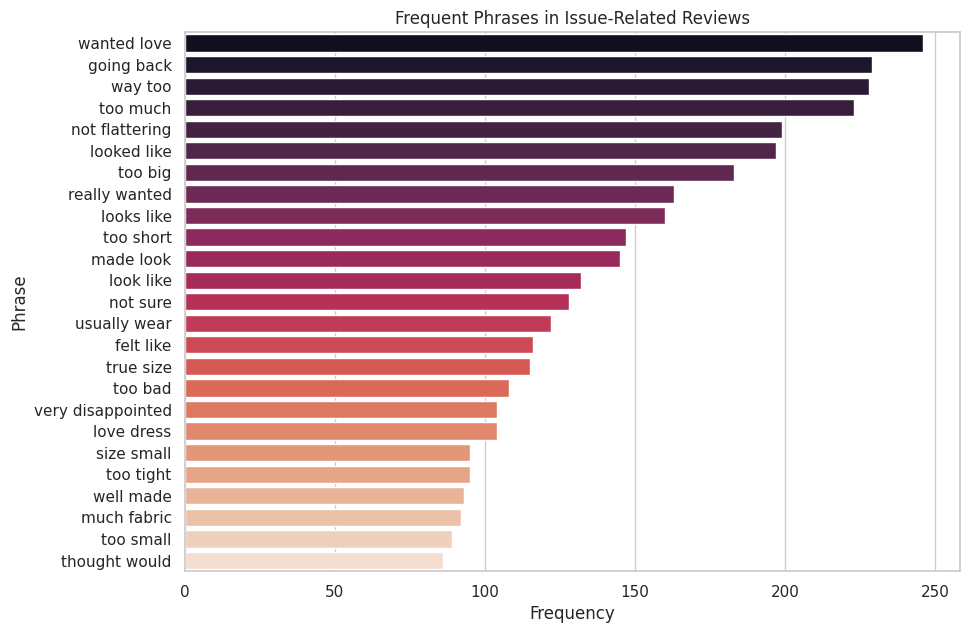

In [34]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_bigrams,
    x="Frequency",
    y="Phrase",
    palette="rocket"
)

plt.title("Frequent Phrases in Issue-Related Reviews")
plt.xlabel("Frequency")
plt.ylabel("Phrase")
plt.show()

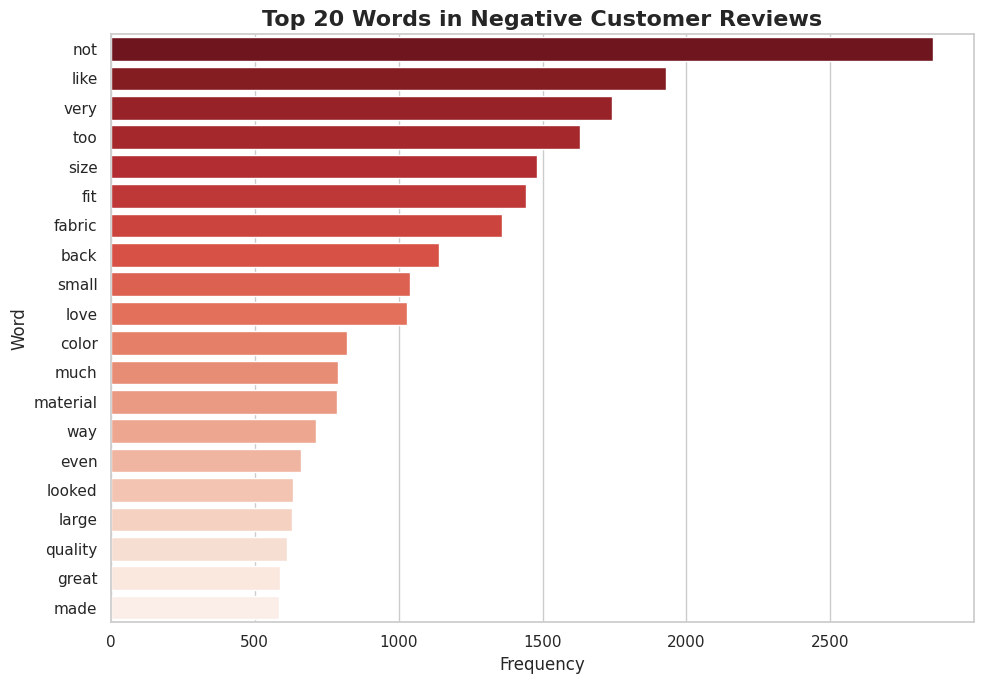

,Word,Frequency
0,not,2856
1,like,1930
2,very,1740
3,too,1631
4,size,1480
5,fit,1444
6,fabric,1359
7,back,1141
8,small,1040
9,love,1029


In [35]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter

negative_words = []

for review in negative_reviews["Clean Review"].dropna():
    negative_words.extend(str(review).split())

unwanted_words = {
    "dress", "top", "shirt", "one", "really",
    "would", "also", "look", "looks", "wear",
    "bought", "ordered", "purchase", "product"
}

filtered_words = [
    word for word in negative_words
    if word not in unwanted_words and len(word) > 2
]

top_words = pd.DataFrame(
    Counter(filtered_words).most_common(20),
    columns=["Word", "Frequency"]
)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_words,
    x="Frequency",
    y="Word",
    palette="Reds_r"
)

plt.title(
    "Top 20 Words in Negative Customer Reviews",
    fontsize=16,
    fontweight="bold"
)
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.tight_layout()
plt.show()

display(top_words)

In [36]:
df["Is Negative Review"] = (
    (df["Rating"] <= 2) |
    (df["Recommended IND"] == 0) |
    (df["VADER Sentiment"] == "Negative")
).astype(int)

product_summary = (
    df.groupby("Clothing ID")
      .agg(
          Review_Count=("Review Text", "size"),
          Average_Rating=("Rating", "mean"),
          Recommendation_Rate=("Recommended IND", "mean"),
          Negative_Review_Count=("Is Negative Review", "sum"),
          Average_Sentiment=("Compound Score", "mean"),
          Department=("Department Name", "first"),
          Product_Class=("Class Name", "first")
      )
      .reset_index()
)

product_summary["Recommendation_Rate"] *= 100

product_summary["Negative_Review_Rate"] = (
    product_summary["Negative_Review_Count"] /
    product_summary["Review_Count"] * 100
)

problem_products = (
    product_summary[
        product_summary["Review_Count"] >= 10
    ]
    .sort_values(
        ["Negative_Review_Rate", "Average_Rating"],
        ascending=[False, True]
    )
)

display(problem_products.head(20).round(2))

,Clothing ID,Review_Count,Average_Rating,Recommendation_Rate,Negative_Review_Count,Average_Sentiment,Department,Product_Class,Negative_Review_Rate
218,229,11,2.18,27.27,8,0.39,Intimate,Legwear,72.73
924,948,10,3.20,50.00,6,0.42,Tops,Sweaters,60.00
462,482,10,3.50,40.00,6,0.59,Intimate,Lounge,60.00
1030,1055,24,3.29,54.17,13,0.53,Bottoms,Pants,54.17
905,929,19,3.11,52.63,10,0.56,Tops,Sweaters,52.63
1121,1146,10,3.60,70.00,5,0.47,Trend,Trend,50.00
992,1016,24,3.33,62.50,11,0.60,Bottoms,Skirts,45.83
860,884,11,3.18,63.64,5,0.70,Tops,Knits,45.45
878,902,16,3.56,62.50,7,0.66,Tops,Fine gauge,43.75
897,921,30,3.77,66.67,13,0.52,Tops,Sweaters,43.33


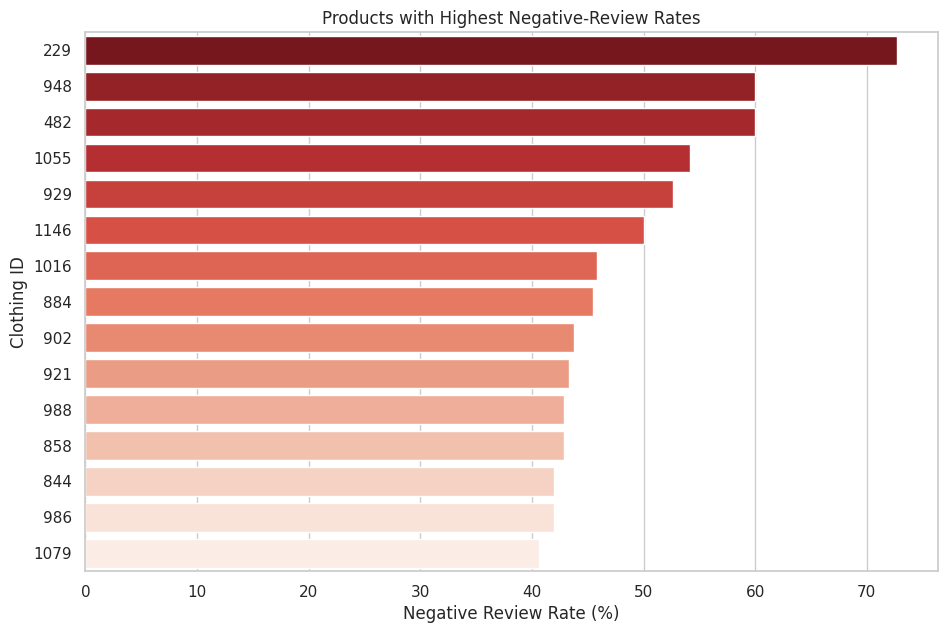

In [37]:
top_problem_products = problem_products.head(15).copy()

top_problem_products["Clothing ID"] = (
    top_problem_products["Clothing ID"].astype(str)
)

plt.figure(figsize=(11, 7))

sns.barplot(
    data=top_problem_products,
    x="Negative_Review_Rate",
    y="Clothing ID",
    palette="Reds_r"
)

plt.title("Products with Highest Negative-Review Rates")
plt.xlabel("Negative Review Rate (%)")
plt.ylabel("Clothing ID")
plt.show()

In [38]:
level1_kpis = pd.DataFrame({
    "Metric": [
        "Total usable reviews",
        "Average rating",
        "Recommendation rate (%)",
        "Positive VADER reviews (%)",
        "Neutral VADER reviews (%)",
        "Negative VADER reviews (%)",
        "Issue-related reviews"
    ],
    "Value": [
        len(df),
        round(df["Rating"].mean(), 2),
        round(df["Recommended IND"].mean() * 100, 2),
        round((df["VADER Sentiment"] == "Positive").mean() * 100, 2),
        round((df["VADER Sentiment"] == "Neutral").mean() * 100, 2),
        round((df["VADER Sentiment"] == "Negative").mean() * 100, 2),
        len(negative_reviews)
    ]
})

display(level1_kpis)

,Metric,Value
0,Total usable reviews,22640.00
1,Average rating,4.18
2,Recommendation rate (%),81.89
3,Positive VADER reviews (%),92.94
4,Neutral VADER reviews (%),1.17
5,Negative VADER reviews (%),5.90
6,Issue-related reviews,4629.00


In [39]:
top_issue = issue_counts.iloc[0]["Issue"]

lowest_rated_department = (
    department_rating
    .sort_values("Average_Rating")
    .iloc[0]["Department Name"]
)

highest_negative_product = (
    problem_products
    .iloc[0]["Clothing ID"]
)

print("LEVEL 1 EXECUTIVE FINDINGS")
print("-" * 40)
print(f"1. Most frequently detected issue: {top_issue}")
print(f"2. Lowest-rated department: {lowest_rated_department}")
print(f"3. Product requiring priority investigation: {highest_negative_product}")
print(
    f"4. Overall recommendation rate: "
    f"{df['Recommended IND'].mean() * 100:.2f}%"
)
print(
    f"5. Average customer rating: "
    f"{df['Rating'].mean():.2f}/5"
)

LEVEL 1 EXECUTIVE FINDINGS
----------------------------------------
1. Most frequently detected issue: Fabric or Material
2. Lowest-rated department: Trend
3. Product requiring priority investigation: 229
4. Overall recommendation rate: 81.89%
5. Average customer rating: 4.18/5


#level2


In [40]:
!pip install -q scikit-learn joblib

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.svm import LinearSVC

Sentiment distribution:
Sentiment
Positive    17447
Neutral      2823
Negative     2370
Name: count, dtype: int64


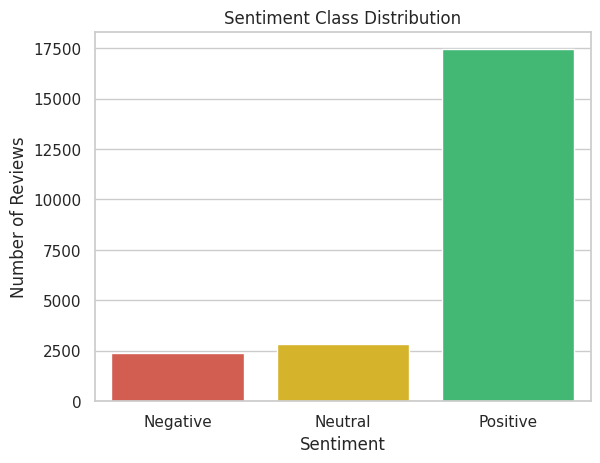

In [42]:
def create_sentiment(rating):
    if rating <= 2:
        return "Negative"
    elif rating == 3:
        return "Neutral"
    else:
        return "Positive"


df["Sentiment"] = df["Rating"].apply(create_sentiment)

print("Sentiment distribution:")
print(df["Sentiment"].value_counts())

sns.countplot(
    data=df,
    x="Sentiment",
    order=["Negative", "Neutral", "Positive"],
    palette=["#e74c3c", "#f1c40f", "#2ecc71"]
)

plt.title("Sentiment Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

In [43]:
# Restore the display function
from IPython.display import display

In [44]:
df["Title"] = df["Title"].fillna("")
df["Review Text"] = df["Review Text"].fillna("")

df["Combined Text"] = (
    df["Title"].astype(str) + " " +
    df["Review Text"].astype(str)
).str.strip()

model_data = df[
    ["Combined Text", "Sentiment"]
].copy()

# Remove empty reviews
model_data = model_data[
    model_data["Combined Text"].str.len() > 0
].reset_index(drop=True)

print("Model data shape:", model_data.shape)

display(model_data.head())

Model data shape: (22640, 2)


,Combined Text,Sentiment
0,No Title Absolutely wonderful - silky and sexy...,Positive
1,No Title Love this dress! it's sooo pretty. ...,Positive
2,Some major design flaws I had such high hopes ...,Neutral
3,"My favorite buy! I love, love, love this jumps...",Positive
4,Flattering shirt This shirt is very flattering...,Positive


In [45]:
def clean_text(text):
    text = str(text).lower()

    # Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)

    # Retain letters and apostrophes
    text = re.sub(r"[^a-z']", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [46]:
X = model_data["Combined Text"]
y = model_data["Sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Reset indexes to avoid alignment errors later
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

print("Training records:", len(X_train))
print("Testing records:", len(X_test))

print("\nTraining sentiment distribution:")
print(y_train.value_counts())

Training records: 18112
Testing records: 4528

Training sentiment distribution:
Sentiment
Positive    13958
Neutral      2258
Negative     1896
Name: count, dtype: int64


In [47]:
sentiment_model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            preprocessor=clean_text,
            stop_words="english",
            ngram_range=(1, 2),
            min_df=3,
            max_df=0.95,
            max_features=20000,
            sublinear_tf=True
        )
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1500,
            class_weight="balanced",
            random_state=42
        )
    )
])

sentiment_model.fit(X_train, y_train)

print("Model training completed successfully.")

Model training completed successfully.


In [48]:
y_pred = sentiment_model.predict(X_test)

print("Number of test records:", len(X_test))
print("Number of predictions:", len(y_pred))
print("First 10 predictions:", y_pred[:10])

Number of test records: 4528
Number of predictions: 4528
First 10 predictions: ['Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Negative' 'Positive' 'Positive']


In [49]:
accuracy = accuracy_score(y_test, y_pred)

print("MODEL EVALUATION")
print("-" * 50)
print(f"Accuracy: {accuracy:.4f}")
print(f"Accuracy Percentage: {accuracy * 100:.2f}%")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        labels=["Negative", "Neutral", "Positive"],
        zero_division=0
    )
)

MODEL EVALUATION
--------------------------------------------------
Accuracy: 0.8087
Accuracy Percentage: 80.87%

Classification Report:
              precision    recall  f1-score   support

    Negative       0.54      0.63      0.58       474
     Neutral       0.38      0.51      0.43       565
    Positive       0.96      0.88      0.92      3489

    accuracy                           0.81      4528
   macro avg       0.62      0.67      0.64      4528
weighted avg       0.84      0.81      0.82      4528



In [50]:
report_dictionary = classification_report(
    y_test,
    y_pred,
    labels=["Negative", "Neutral", "Positive"],
    output_dict=True,
    zero_division=0
)

evaluation_table = pd.DataFrame(
    report_dictionary
).transpose()

display(evaluation_table.round(3))

,precision,recall,f1-score,support
Negative,0.537,0.631,0.580,474.000
Neutral,0.378,0.512,0.435,565.000
Positive,0.959,0.881,0.918,3489.000
accuracy,0.809,0.809,0.809,0.809
macro avg,0.624,0.674,0.644,4528.000
weighted avg,0.842,0.809,0.823,4528.000


Confusion Matrix:
[[ 299  151   24]
 [ 168  289  108]
 [  90  325 3074]]


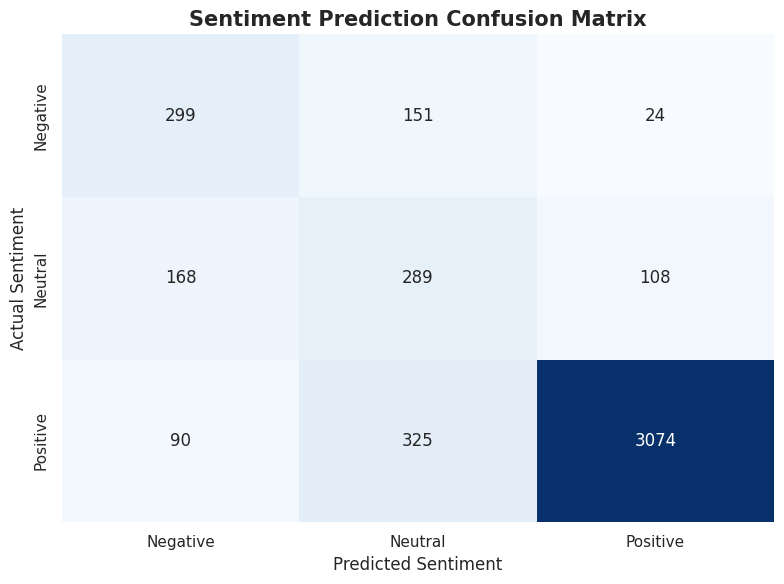

In [51]:
class_names = ["Negative", "Neutral", "Positive"]

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=class_names
)

print("Confusion Matrix:")
print(cm)

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    cbar=False,
    ax=ax
)

ax.set_title(
    "Sentiment Prediction Confusion Matrix",
    fontsize=15,
    fontweight="bold"
)
ax.set_xlabel("Predicted Sentiment")
ax.set_ylabel("Actual Sentiment")

plt.tight_layout()
plt.show()

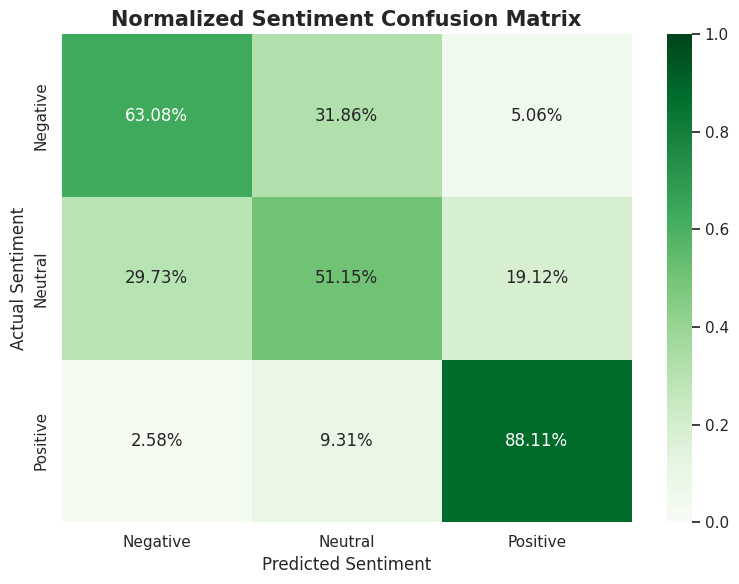

In [52]:
cm_normalized = confusion_matrix(
    y_test,
    y_pred,
    labels=class_names,
    normalize="true"
)

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2%",
    cmap="Greens",
    xticklabels=class_names,
    yticklabels=class_names,
    cbar=True,
    vmin=0,
    vmax=1,
    ax=ax
)

ax.set_title(
    "Normalized Sentiment Confusion Matrix",
    fontsize=15,
    fontweight="bold"
)
ax.set_xlabel("Predicted Sentiment")
ax.set_ylabel("Actual Sentiment")

plt.tight_layout()
plt.show()

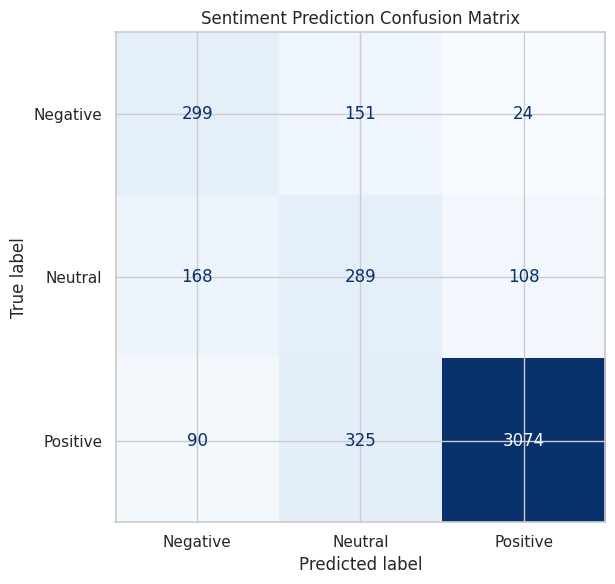

In [53]:
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=class_names
)

cm_plot = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8, 6))

cm_plot.plot(
    cmap="Blues",
    values_format="d",
    ax=ax,
    colorbar=False
)

ax.set_title("Sentiment Prediction Confusion Matrix")
plt.tight_layout()
plt.show()

In [54]:
prediction_results = pd.DataFrame({
    "Review": X_test.to_numpy(),
    "Actual Sentiment": y_test.to_numpy(),
    "Predicted Sentiment": y_pred
})

prediction_results["Correct Prediction"] = (
    prediction_results["Actual Sentiment"] ==
    prediction_results["Predicted Sentiment"]
)

display(prediction_results.head(20))

,Review,Actual Sentiment,Predicted Sentiment,Correct Prediction
0,No Title Very cute everyday tee. usually run b...,Positive,Positive,True
1,Loooovvvvveee This shirt is so comfortable and...,Positive,Positive,True
2,"Interesting neckline I like this dress a lot, ...",Positive,Positive,True
3,How beautiful is that! This is a treasure and ...,Positive,Positive,True
4,Fun change from the norm Fun detail with the b...,Positive,Positive,True
5,Flowy and comfy This top is very flattering on...,Positive,Positive,True
6,"Stretchs out Stretch out fast\r\n\r\n5,8 130lb...",Neutral,Positive,False
7,"Drab color, weird fit Couldn't make it work, e...",Negative,Negative,True
8,Great style and colors I am five four and one ...,Positive,Positive,True
9,Runs at least two sizes small This is one of t...,Neutral,Positive,False


In [55]:
correct_count = prediction_results[
    "Correct Prediction"
].sum()

incorrect_count = (
    len(prediction_results) - correct_count
)

print("Total test predictions:", len(prediction_results))
print("Correct predictions:", correct_count)
print("Incorrect predictions:", incorrect_count)
print(
    "Accuracy:",
    round(
        correct_count /
        len(prediction_results) * 100,
        2
    ),
    "%"
)

Total test predictions: 4528
Correct predictions: 3662
Incorrect predictions: 866
Accuracy: 80.87 %


In [56]:
incorrect_predictions = prediction_results[
    prediction_results["Correct Prediction"] == False
].reset_index(drop=True)

print(
    "Number of incorrect predictions:",
    len(incorrect_predictions)
)

display(incorrect_predictions.head(20))

Number of incorrect predictions: 866


,Review,Actual Sentiment,Predicted Sentiment,Correct Prediction
0,"Stretchs out Stretch out fast\r\n\r\n5,8 130lb...",Neutral,Positive,False
1,Runs at least two sizes small This is one of t...,Neutral,Positive,False
2,"No Title I got this in a medium, its really bi...",Positive,Neutral,False
3,"Pretty pattern, weird texture I love the desig...",Positive,Neutral,False
4,Beautiful if you're tall enough These pants ar...,Neutral,Positive,False
5,Cute! Love this shirt. i have it in black. i ...,Positive,Neutral,False
6,Disappointing I really wanted to love this dre...,Neutral,Negative,False
7,Seeeee thru! This is baggy on me in my regular...,Neutral,Positive,False
8,Nice top?? I love this designer and decided to...,Positive,Neutral,False
9,Whimsical This is a cute blouse. i get lots of...,Neutral,Positive,False


In [57]:
new_reviews = [
    "The dress is beautiful and fits perfectly.",
    "The material is cheap and the size is too small.",
    "The product is okay but nothing special.",
    "I love the color and the quality is excellent.",
    "The stitching came apart after the first wash."
]

new_predictions = sentiment_model.predict(
    new_reviews
)

new_probabilities = sentiment_model.predict_proba(
    new_reviews
)

new_review_results = pd.DataFrame({
    "Review": new_reviews,
    "Predicted Sentiment": new_predictions,
    "Confidence": new_probabilities.max(axis=1)
})

new_review_results["Confidence"] = (
    new_review_results["Confidence"] * 100
).round(2).astype(str) + "%"

display(new_review_results)

,Review,Predicted Sentiment,Confidence
0,The dress is beautiful and fits perfectly.,Positive,96.76%
1,The material is cheap and the size is too small.,Negative,86.26%
2,The product is okay but nothing special.,Neutral,72.3%
3,I love the color and the quality is excellent.,Positive,60.84%
4,The stitching came apart after the first wash.,Negative,82.94%


In [58]:
probability_results = pd.DataFrame(
    new_probabilities,
    columns=sentiment_model.named_steps[
        "classifier"
    ].classes_
)

probability_results.insert(
    0,
    "Review",
    new_reviews
)

display(probability_results.round(3))

,Review,Negative,Neutral,Positive
0,The dress is beautiful and fits perfectly.,0.012,0.021,0.968
1,The material is cheap and the size is too small.,0.863,0.112,0.025
2,The product is okay but nothing special.,0.243,0.723,0.034
3,I love the color and the quality is excellent.,0.172,0.219,0.608
4,The stitching came apart after the first wash.,0.829,0.138,0.032


In [59]:
def predict_review_sentiment(review_text):
    prediction = sentiment_model.predict(
        [review_text]
    )[0]

    probabilities = sentiment_model.predict_proba(
        [review_text]
    )[0]

    class_labels = sentiment_model.named_steps[
        "classifier"
    ].classes_

    result = {
        "Review": review_text,
        "Predicted Sentiment": prediction,
        "Confidence": round(
            float(probabilities.max()) * 100,
            2
        )
    }

    for label, probability in zip(
        class_labels,
        probabilities
    ):
        result[f"{label} Probability"] = round(
            float(probability) * 100,
            2
        )

    return result

##Test Function

In [60]:
sample_review = """
The top looks attractive, but the material is thin,
the size is too small, and the stitching is poor.
"""

result = predict_review_sentiment(sample_review)

result

{'Review': '\nThe top looks attractive, but the material is thin,\nthe size is too small, and the stitching is poor.\n',
 'Predicted Sentiment': 'Negative',
 'Confidence': 85.65,
 'Negative Probability': 85.65,
 'Neutral Probability': 11.59,
 'Positive Probability': 2.75}

In [61]:
tfidf_vectorizer = sentiment_model.named_steps[
    "tfidf"
]

logistic_classifier = sentiment_model.named_steps[
    "classifier"
]

feature_names = np.array(
    tfidf_vectorizer.get_feature_names_out()
)

for class_index, class_name in enumerate(
    logistic_classifier.classes_
):
    coefficients = logistic_classifier.coef_[
        class_index
    ]

    top_indices = np.argsort(
        coefficients
    )[-15:][::-1]

    important_terms = pd.DataFrame({
        "Term": feature_names[top_indices],
        "Importance Score": coefficients[top_indices]
    })

    print(
        f"\nTop terms associated with "
        f"{class_name} sentiment:"
    )

    display(important_terms)


Top terms associated with Negative sentiment:


,Term,Importance Score
0,disappointed,4.022128
1,horrible,3.272679
2,unflattering,3.145713
3,awful,3.105468
4,huge,2.903570
5,wanted love,2.824588
6,disappointing,2.769173
7,terrible,2.739597
8,cheap,2.703430
9,poor,2.596356



Top terms associated with Neutral sentiment:


,Term,Importance Score
0,ok,2.262515
1,unfortunately,1.980162
2,just ok,1.886655
3,issues,1.784773
4,wanted love,1.780641
5,meh,1.726188
6,arms,1.718756
7,love style,1.648326
8,want love,1.620276
9,removed,1.613096



Top terms associated with Positive sentiment:


,Term,Importance Score
0,love,5.595057
1,perfect,5.034946
2,great,4.423319
3,comfortable,4.297143
4,little,3.038180
5,unique,2.912963
6,soft,2.782828
7,compliments,2.751891
8,comfy,2.728288
9,happy,2.724789


In [62]:
svm_model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            preprocessor=clean_text,
            stop_words="english",
            ngram_range=(1, 2),
            min_df=3,
            max_df=0.95,
            max_features=20000,
            sublinear_tf=True
        )
    ),
    (
        "classifier",
        LinearSVC(
            class_weight="balanced",
            random_state=42
        )
    )
])

svm_model.fit(X_train, y_train)

svm_predictions = svm_model.predict(X_test)

svm_accuracy = accuracy_score(
    y_test,
    svm_predictions
)

print(
    f"Linear SVM Accuracy: "
    f"{svm_accuracy * 100:.2f}%"
)

print("\nLinear SVM Classification Report:")

print(
    classification_report(
        y_test,
        svm_predictions,
        labels=class_names,
        zero_division=0
    )
)

Linear SVM Accuracy: 82.24%

Linear SVM Classification Report:
              precision    recall  f1-score   support

    Negative       0.57      0.55      0.56       474
     Neutral       0.38      0.35      0.36       565
    Positive       0.92      0.94      0.93      3489

    accuracy                           0.82      4528
   macro avg       0.62      0.61      0.62      4528
weighted avg       0.81      0.82      0.82      4528



In [63]:
logistic_report = classification_report(
    y_test,
    y_pred,
    labels=class_names,
    output_dict=True,
    zero_division=0
)

svm_report = classification_report(
    y_test,
    svm_predictions,
    labels=class_names,
    output_dict=True,
    zero_division=0
)

model_comparison = pd.DataFrame({
    "Model": [
        "TF-IDF + Logistic Regression",
        "TF-IDF + Linear SVM"
    ],
    "Accuracy": [
        accuracy,
        svm_accuracy
    ],
    "Weighted Precision": [
        logistic_report["weighted avg"]["precision"],
        svm_report["weighted avg"]["precision"]
    ],
    "Weighted Recall": [
        logistic_report["weighted avg"]["recall"],
        svm_report["weighted avg"]["recall"]
    ],
    "Weighted F1-Score": [
        logistic_report["weighted avg"]["f1-score"],
        svm_report["weighted avg"]["f1-score"]
    ]
})

display(
    model_comparison
    .sort_values(
        "Weighted F1-Score",
        ascending=False
    )
    .round(4)
)

,Model,Accuracy,Weighted Precision,Weighted Recall,Weighted F1-Score
0,TF-IDF + Logistic Regression,0.8087,0.8421,0.8087,0.8225
1,TF-IDF + Linear SVM,0.8224,0.8149,0.8224,0.8185


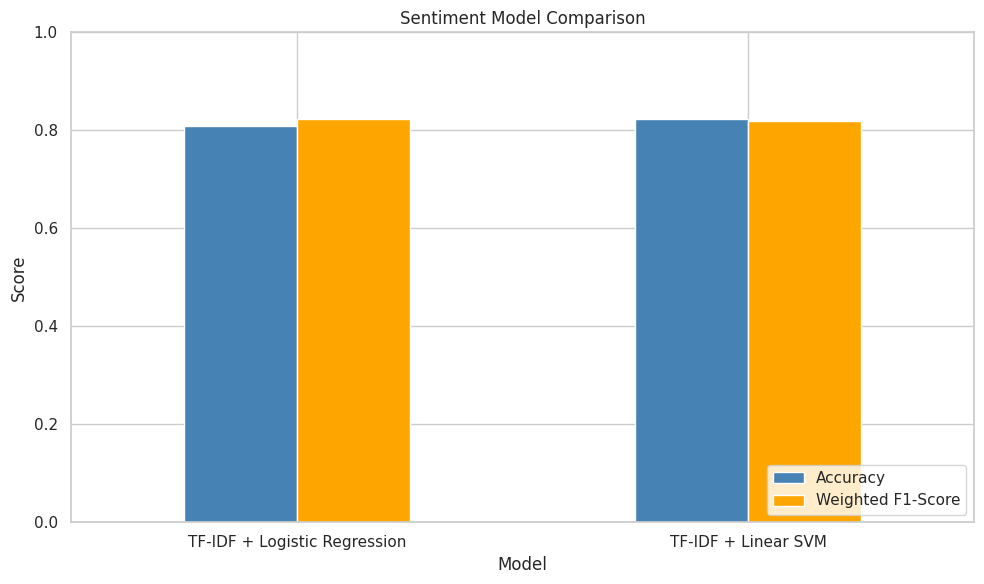

In [64]:
comparison_chart = model_comparison.set_index(
    "Model"
)[
    ["Accuracy", "Weighted F1-Score"]
]

comparison_chart.plot(
    kind="bar",
    figsize=(10, 6),
    color=["steelblue", "orange"]
)

plt.title("Sentiment Model Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [65]:
import joblib

prediction_results.to_csv(
    "level2_sentiment_predictions.csv",
    index=False
)

model_comparison.to_csv(
    "level2_model_comparison.csv",
    index=False
)

joblib.dump(
    sentiment_model,
    "sentiment_prediction_model.pkl"
)

print("Level 2 results and model saved successfully.")

Level 2 results and model saved successfully.


In [66]:
from google.colab import files

files.download("level2_sentiment_predictions.csv")
files.download("level2_model_comparison.csv")
files.download("sentiment_prediction_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Level-3

### Prepare the issue information

In [67]:
# Convert the list of reported issues into separate rows
issue_details = (
    negative_reviews[
        [
            "Clothing ID",
            "Department Name",
            "Class Name",
            "Rating",
            "Recommended IND",
            "Reported Issues"
        ]
    ]
    .explode("Reported Issues")
    .rename(columns={
        "Reported Issues": "Issue"
    })
    .reset_index(drop=True)
)

# Remove unclassified issues
issue_details = issue_details[
    issue_details["Issue"] != "Other/Unclassified"
].copy()

display(issue_details.head())

,Clothing ID,Department Name,Class Name,Rating,Recommended IND,Issue
0,1077,Dresses,Dresses,3,0,Size Runs Small
1,1077,Dresses,Dresses,3,0,Poor Quality
2,1077,Dresses,Dresses,3,0,Length Issue
3,1077,Dresses,Dresses,3,0,Design Problem
4,1077,Dresses,Dresses,3,0,Stitching or Seam


### Calculate issue frequency

In [68]:
issue_summary = (
    issue_details
    .groupby("Issue")
    .agg(
        Issue_Count=("Issue", "size"),
        Average_Rating=("Rating", "mean"),
        Recommendation_Rate=("Recommended IND", "mean"),
        Affected_Products=("Clothing ID", "nunique")
    )
    .reset_index()
)

issue_summary["Recommendation_Rate"] = (
    issue_summary["Recommendation_Rate"] * 100
)

issue_summary = issue_summary.sort_values(
    "Issue_Count",
    ascending=False
).reset_index(drop=True)

display(issue_summary.round(2))

,Issue,Issue_Count,Average_Rating,Recommendation_Rate,Affected_Products
0,Fabric or Material,1871,2.40,8.55,331
1,Length Issue,791,2.58,12.90,226
2,Color Mismatch,758,2.54,11.74,215
3,Design Problem,683,2.43,9.22,210
4,Size Runs Large,588,2.58,15.31,195
5,Size Runs Small,511,2.51,15.26,177
6,Poor Quality,476,2.13,4.62,173
7,Stitching or Seam,343,2.37,11.66,132
8,Poor Fit,304,2.22,5.59,141
9,Damaged or Defective,145,2.14,5.52,83


### Map each issue to a business action

In [69]:
recommendation_map = {
    "Size Runs Small": {
        "Recommended Action":
            "Review garment measurements, update the size chart, "
            "and add a 'runs small' message to the product page.",

        "Responsible Team":
            "Merchandising and Product Sizing",

        "KPI":
            "Sizing complaint rate and size-related return rate"
    },

    "Size Runs Large": {
        "Recommended Action":
            "Verify garment measurements, update the size chart, "
            "and add a 'runs large' fit warning.",

        "Responsible Team":
            "Merchandising and Product Sizing",

        "KPI":
            "Sizing complaint rate and size-related return rate"
    },

    "Poor Fit": {
        "Recommended Action":
            "Review the garment pattern and fit specifications, "
            "perform fit testing, and provide model measurements.",

        "Responsible Team":
            "Product Design and Merchandising",

        "KPI":
            "Fit complaint rate and recommendation rate"
    },

    "Poor Quality": {
        "Recommended Action":
            "Inspect the product batch, review supplier quality, "
            "and strengthen pre-shipment quality checks.",

        "Responsible Team":
            "Quality Assurance and Supplier Management",

        "KPI":
            "Quality complaint rate and defective-product return rate"
    },

    "Fabric or Material": {
        "Recommended Action":
            "Review fabric specifications, test comfort and durability, "
            "and improve material descriptions on the product page.",

        "Responsible Team":
            "Sourcing and Quality Assurance",

        "KPI":
            "Material complaint rate and average product rating"
    },

    "Color Mismatch": {
        "Recommended Action":
            "Update product photography under consistent lighting "
            "and provide a more accurate color description.",

        "Responsible Team":
            "E-commerce Content and Photography",

        "KPI":
            "Color-related complaint and return rate"
    },

    "Length Issue": {
        "Recommended Action":
            "Display exact garment lengths and add petite, regular, "
            "or tall fit guidance where appropriate.",

        "Responsible Team":
            "Merchandising and E-commerce Content",

        "KPI":
            "Length-related complaint and return rate"
    },

    "Design Problem": {
        "Recommended Action":
            "Review design elements reported by customers and perform "
            "wear tests before producing the next batch.",

        "Responsible Team":
            "Product Design",

        "KPI":
            "Design complaint rate and average rating"
    },

    "Damaged or Defective": {
        "Recommended Action":
            "Quarantine the affected batch, inspect inventory, "
            "and introduce stricter final-product inspections.",

        "Responsible Team":
            "Quality Control and Warehouse Operations",

        "KPI":
            "Defect rate and damaged-product return rate"
    },

    "Stitching or Seam": {
        "Recommended Action":
            "Inspect stitching standards, seam strength, zippers, "
            "and buttons, and request corrective action from suppliers.",

        "Responsible Team":
            "Quality Assurance and Supplier Management",

        "KPI":
            "Stitching complaint rate and defect return rate"
    },

    "Shrinkage": {
        "Recommended Action":
            "Conduct wash tests, review fabric treatment, and provide "
            "clear washing and care instructions.",

        "Responsible Team":
            "Quality Assurance and E-commerce Content",

        "KPI":
            "Shrinkage complaint rate and post-wash return rate"
    }
}

### Add recommendations to the issue summary

In [70]:
issue_summary["Recommended Action"] = issue_summary[
    "Issue"
].map(
    lambda issue: recommendation_map.get(
        issue,
        {}
    ).get(
        "Recommended Action",
        "Manually review customer comments and investigate the issue."
    )
)

issue_summary["Responsible Team"] = issue_summary[
    "Issue"
].map(
    lambda issue: recommendation_map.get(
        issue,
        {}
    ).get(
        "Responsible Team",
        "Customer Experience and Quality Assurance"
    )
)

issue_summary["KPI"] = issue_summary[
    "Issue"
].map(
    lambda issue: recommendation_map.get(
        issue,
        {}
    ).get(
        "KPI",
        "Complaint rate and average rating"
    )
)

display(issue_summary.head())

,Issue,Issue_Count,Average_Rating,Recommendation_Rate,Affected_Products,Recommended Action,Responsible Team,KPI
0,Fabric or Material,1871,2.404596,8.551577,331,"Review fabric specifications, test comfort and...",Sourcing and Quality Assurance,Material complaint rate and average product ra...
1,Length Issue,791,2.579014,12.895070,226,"Display exact garment lengths and add petite, ...",Merchandising and E-commerce Content,Length-related complaint and return rate
2,Color Mismatch,758,2.544855,11.741425,215,Update product photography under consistent li...,E-commerce Content and Photography,Color-related complaint and return rate
3,Design Problem,683,2.431918,9.224012,210,Review design elements reported by customers a...,Product Design,Design complaint rate and average rating
4,Size Runs Large,588,2.578231,15.306122,195,"Verify garment measurements, update the size c...",Merchandising and Product Sizing,Sizing complaint rate and size-related return ...


### Assign business priority

In [71]:
# Frequency score: higher count means higher risk
issue_summary["Frequency_Score"] = pd.qcut(
    issue_summary["Issue_Count"].rank(method="first"),
    q=3,
    labels=[1, 2, 3]
).astype(int)

# Rating score: lower ratings mean higher risk
issue_summary["Rating_Risk_Score"] = np.select(
    [
        issue_summary["Average_Rating"] <= 2.5,
        issue_summary["Average_Rating"] <= 3.5
    ],
    [
        3,
        2
    ],
    default=1
)

# Recommendation score: lower recommendation rate means higher risk
issue_summary["Recommendation_Risk_Score"] = np.select(
    [
        issue_summary["Recommendation_Rate"] < 40,
        issue_summary["Recommendation_Rate"] < 70
    ],
    [
        3,
        2
    ],
    default=1
)

issue_summary["Priority_Score"] = (
    issue_summary["Frequency_Score"] +
    issue_summary["Rating_Risk_Score"] +
    issue_summary["Recommendation_Risk_Score"]
)

### Convert priority score into business labels

In [72]:
def assign_priority(score):
    if score >= 8:
        return "Critical"
    elif score >= 6:
        return "High"
    elif score >= 4:
        return "Medium"
    else:
        return "Low"


issue_summary["Priority"] = issue_summary[
    "Priority_Score"
].apply(assign_priority)

priority_order = {
    "Critical": 1,
    "High": 2,
    "Medium": 3,
    "Low": 4
}

issue_summary["Priority_Order"] = (
    issue_summary["Priority"].map(priority_order)
)

issue_summary = issue_summary.sort_values(
    ["Priority_Order", "Issue_Count"],
    ascending=[True, False]
).reset_index(drop=True)

display(
    issue_summary[
        [
            "Issue",
            "Issue_Count",
            "Average_Rating",
            "Recommendation_Rate",
            "Priority_Score",
            "Priority",
            "Responsible Team",
            "Recommended Action",
            "KPI"
        ]
    ].round(2)
)

,Issue,Issue_Count,Average_Rating,Recommendation_Rate,Priority_Score,Priority,Responsible Team,Recommended Action,KPI
0,Fabric or Material,1871,2.40,8.55,9,Critical,Sourcing and Quality Assurance,"Review fabric specifications, test comfort and...",Material complaint rate and average product ra...
1,Length Issue,791,2.58,12.90,8,Critical,Merchandising and E-commerce Content,"Display exact garment lengths and add petite, ...",Length-related complaint and return rate
2,Color Mismatch,758,2.54,11.74,8,Critical,E-commerce Content and Photography,Update product photography under consistent li...,Color-related complaint and return rate
3,Design Problem,683,2.43,9.22,9,Critical,Product Design,Review design elements reported by customers a...,Design complaint rate and average rating
4,Poor Quality,476,2.13,4.62,8,Critical,Quality Assurance and Supplier Management,"Inspect the product batch, review supplier qua...",Quality complaint rate and defective-product r...
5,Size Runs Large,588,2.58,15.31,7,High,Merchandising and Product Sizing,"Verify garment measurements, update the size c...",Sizing complaint rate and size-related return ...
6,Size Runs Small,511,2.51,15.26,7,High,Merchandising and Product Sizing,"Review garment measurements, update the size c...",Sizing complaint rate and size-related return ...
7,Stitching or Seam,343,2.37,11.66,7,High,Quality Assurance and Supplier Management,"Inspect stitching standards, seam strength, zi...",Stitching complaint rate and defect return rate
8,Poor Fit,304,2.22,5.59,7,High,Product Design and Merchandising,Review the garment pattern and fit specificati...,Fit complaint rate and recommendation rate
9,Damaged or Defective,145,2.14,5.52,7,High,Quality Control and Warehouse Operations,"Quarantine the affected batch, inspect invento...",Defect rate and damaged-product return rate


### Add a suggested timeline




In [73]:
timeline_map = {
    "Critical": "Immediate: 0–7 days",
    "High": "Short term: 8–30 days",
    "Medium": "Medium term: 31–60 days",
    "Low": "Monitor: 61–90 days"
}

issue_summary["Suggested Timeline"] = (
    issue_summary["Priority"].map(timeline_map)
)

display(
    issue_summary[
        [
            "Issue",
            "Priority",
            "Suggested Timeline",
            "Responsible Team",
            "Recommended Action",
            "KPI"
        ]
    ]
)

,Issue,Priority,Suggested Timeline,Responsible Team,Recommended Action,KPI
0,Fabric or Material,Critical,Immediate: 0–7 days,Sourcing and Quality Assurance,"Review fabric specifications, test comfort and...",Material complaint rate and average product ra...
1,Length Issue,Critical,Immediate: 0–7 days,Merchandising and E-commerce Content,"Display exact garment lengths and add petite, ...",Length-related complaint and return rate
2,Color Mismatch,Critical,Immediate: 0–7 days,E-commerce Content and Photography,Update product photography under consistent li...,Color-related complaint and return rate
3,Design Problem,Critical,Immediate: 0–7 days,Product Design,Review design elements reported by customers a...,Design complaint rate and average rating
4,Poor Quality,Critical,Immediate: 0–7 days,Quality Assurance and Supplier Management,"Inspect the product batch, review supplier qua...",Quality complaint rate and defective-product r...
5,Size Runs Large,High,Short term: 8–30 days,Merchandising and Product Sizing,"Verify garment measurements, update the size c...",Sizing complaint rate and size-related return ...
6,Size Runs Small,High,Short term: 8–30 days,Merchandising and Product Sizing,"Review garment measurements, update the size c...",Sizing complaint rate and size-related return ...
7,Stitching or Seam,High,Short term: 8–30 days,Quality Assurance and Supplier Management,"Inspect stitching standards, seam strength, zi...",Stitching complaint rate and defect return rate
8,Poor Fit,High,Short term: 8–30 days,Product Design and Merchandising,Review the garment pattern and fit specificati...,Fit complaint rate and recommendation rate
9,Damaged or Defective,High,Short term: 8–30 days,Quality Control and Warehouse Operations,"Quarantine the affected batch, inspect invento...",Defect rate and damaged-product return rate


### Create department-level recommendations

In [74]:
department_issue_summary = (
    issue_details
    .groupby(
        ["Department Name", "Issue"]
    )
    .agg(
        Issue_Count=("Issue", "size"),
        Average_Rating=("Rating", "mean"),
        Recommendation_Rate=("Recommended IND", "mean"),
        Affected_Products=("Clothing ID", "nunique")
    )
    .reset_index()
)

department_issue_summary["Recommendation_Rate"] *= 100

# Find the most frequent issue in each department
top_department_issues = (
    department_issue_summary
    .sort_values(
        ["Department Name", "Issue_Count"],
        ascending=[True, False]
    )
    .groupby(
        "Department Name",
        as_index=False
    )
    .first()
)

top_department_issues["Recommended Action"] = (
    top_department_issues["Issue"].map(
        lambda issue: recommendation_map.get(
            issue,
            {}
        ).get(
            "Recommended Action",
            "Review customer complaints and investigate the product."
        )
    )
)

top_department_issues["Responsible Team"] = (
    top_department_issues["Issue"].map(
        lambda issue: recommendation_map.get(
            issue,
            {}
        ).get(
            "Responsible Team",
            "Customer Experience and Quality Assurance"
        )
    )
)

display(top_department_issues.round(2))

,Department Name,Issue,Issue_Count,Average_Rating,Recommendation_Rate,Affected_Products,Recommended Action,Responsible Team
0,Bottoms,Fabric or Material,250,2.50,11.20,80,"Review fabric specifications, test comfort and...",Sourcing and Quality Assurance
1,Dresses,Fabric or Material,615,2.43,7.32,38,"Review fabric specifications, test comfort and...",Sourcing and Quality Assurance
2,Intimate,Fabric or Material,88,2.30,7.95,82,"Review fabric specifications, test comfort and...",Sourcing and Quality Assurance
3,Jackets,Fabric or Material,73,2.34,12.33,24,"Review fabric specifications, test comfort and...",Sourcing and Quality Assurance
4,Tops,Fabric or Material,826,2.38,7.99,94,"Review fabric specifications, test comfort and...",Sourcing and Quality Assurance
5,Trend,Fabric or Material,19,2.21,26.32,13,"Review fabric specifications, test comfort and...",Sourcing and Quality Assurance


### Create product-level recommendations

In [75]:
priority_products = (
    product_summary[
        product_summary["Review_Count"] >= 10
    ]
    .sort_values(
        ["Negative_Review_Rate", "Average_Rating"],
        ascending=[False, True]
    )
    .head(20)
    .copy()
)

display(priority_products.round(2))

,Clothing ID,Review_Count,Average_Rating,Recommendation_Rate,Negative_Review_Count,Average_Sentiment,Department,Product_Class,Negative_Review_Rate
218,229,11,2.18,27.27,8,0.39,Intimate,Legwear,72.73
924,948,10,3.20,50.00,6,0.42,Tops,Sweaters,60.00
462,482,10,3.50,40.00,6,0.59,Intimate,Lounge,60.00
1030,1055,24,3.29,54.17,13,0.53,Bottoms,Pants,54.17
905,929,19,3.11,52.63,10,0.56,Tops,Sweaters,52.63
1121,1146,10,3.60,70.00,5,0.47,Trend,Trend,50.00
992,1016,24,3.33,62.50,11,0.60,Bottoms,Skirts,45.83
860,884,11,3.18,63.64,5,0.70,Tops,Knits,45.45
878,902,16,3.56,62.50,7,0.66,Tops,Fine gauge,43.75
897,921,30,3.77,66.67,13,0.52,Tops,Sweaters,43.33


### Find the most frequent issue for each problematic product

In [76]:
product_top_issue = (
    issue_details
    .groupby(
        ["Clothing ID", "Issue"]
    )
    .size()
    .reset_index(name="Issue_Count")
    .sort_values(
        ["Clothing ID", "Issue_Count"],
        ascending=[True, False]
    )
    .groupby(
        "Clothing ID",
        as_index=False
    )
    .first()
)

priority_products = priority_products.merge(
    product_top_issue,
    on="Clothing ID",
    how="left"
)

priority_products["Recommended Action"] = (
    priority_products["Issue"].map(
        lambda issue: recommendation_map.get(
            issue,
            {}
        ).get(
            "Recommended Action",
            "Manually review this product and its customer complaints."
        )
    )
)

priority_products["Responsible Team"] = (
    priority_products["Issue"].map(
        lambda issue: recommendation_map.get(
            issue,
            {}
        ).get(
            "Responsible Team",
            "Customer Experience and Quality Assurance"
        )
    )
)

### Assign product-level priority

In [77]:
def assign_product_priority(row):
    if (
        row["Negative_Review_Rate"] >= 50
        and row["Average_Rating"] <= 3
    ):
        return "Critical"

    elif (
        row["Negative_Review_Rate"] >= 35
        or row["Average_Rating"] <= 3
    ):
        return "High"

    elif row["Negative_Review_Rate"] >= 20:
        return "Medium"

    else:
        return "Low"


priority_products["Priority"] = priority_products.apply(
    assign_product_priority,
    axis=1
)

priority_products["Suggested Timeline"] = (
    priority_products["Priority"].map(timeline_map)
)

display(
    priority_products[
        [
            "Clothing ID",
            "Department",
            "Product_Class",
            "Review_Count",
            "Average_Rating",
            "Recommendation_Rate",
            "Negative_Review_Rate",
            "Issue",
            "Priority",
            "Suggested Timeline",
            "Responsible Team",
            "Recommended Action"
        ]
    ].round(2)
)

,Clothing ID,Department,Product_Class,Review_Count,Average_Rating,Recommendation_Rate,Negative_Review_Rate,Issue,Priority,Suggested Timeline,Responsible Team,Recommended Action
0,229,Intimate,Legwear,11,2.18,27.27,72.73,Size Runs Large,Critical,Immediate: 0–7 days,Merchandising and Product Sizing,"Verify garment measurements, update the size c..."
1,948,Tops,Sweaters,10,3.20,50.00,60.00,Fabric or Material,High,Short term: 8–30 days,Sourcing and Quality Assurance,"Review fabric specifications, test comfort and..."
2,482,Intimate,Lounge,10,3.50,40.00,60.00,Design Problem,High,Short term: 8–30 days,Product Design,Review design elements reported by customers a...
3,1055,Bottoms,Pants,24,3.29,54.17,54.17,Fabric or Material,High,Short term: 8–30 days,Sourcing and Quality Assurance,"Review fabric specifications, test comfort and..."
4,929,Tops,Sweaters,19,3.11,52.63,52.63,Fabric or Material,High,Short term: 8–30 days,Sourcing and Quality Assurance,"Review fabric specifications, test comfort and..."
5,1146,Trend,Trend,10,3.60,70.00,50.00,Fabric or Material,High,Short term: 8–30 days,Sourcing and Quality Assurance,"Review fabric specifications, test comfort and..."
6,1016,Bottoms,Skirts,24,3.33,62.50,45.83,Fabric or Material,High,Short term: 8–30 days,Sourcing and Quality Assurance,"Review fabric specifications, test comfort and..."
7,884,Tops,Knits,11,3.18,63.64,45.45,Fabric or Material,High,Short term: 8–30 days,Sourcing and Quality Assurance,"Review fabric specifications, test comfort and..."
8,902,Tops,Fine gauge,16,3.56,62.50,43.75,Color Mismatch,High,Short term: 8–30 days,E-commerce Content and Photography,Update product photography under consistent li...
9,921,Tops,Sweaters,30,3.77,66.67,43.33,Fabric or Material,High,Short term: 8–30 days,Sourcing and Quality Assurance,"Review fabric specifications, test comfort and..."


### Add sentiment-model recommendations

In [78]:
def convert_prediction_to_action(
    predicted_sentiment,
    confidence
):
    confidence_percentage = confidence * 100

    if (
        predicted_sentiment == "Negative"
        and confidence_percentage >= 80
    ):
        return {
            "Priority": "Critical",
            "Action":
                "Create an immediate customer-service alert and "
                "send the review for issue investigation.",
            "Timeline": "Within 24 hours"
        }

    elif predicted_sentiment == "Negative":
        return {
            "Priority": "High",
            "Action":
                "Send the review to the customer-service and "
                "quality-assurance queues.",
            "Timeline": "Within 48 hours"
        }

    elif predicted_sentiment == "Neutral":
        return {
            "Priority": "Medium",
            "Action":
                "Review the feedback for improvement opportunities "
                "and monitor similar comments.",
            "Timeline": "Within 7 days"
        }

    else:
        return {
            "Priority": "Low",
            "Action":
                "Record the positive feedback and identify useful "
                "product strengths for marketing.",
            "Timeline": "Monthly review"
        }

### Example

In [85]:
new_review = """
The fabric feels cheap, the size is too small,
and the zipper stopped working.
"""

prediction = sentiment_model.predict(
    [new_review]
)[0]

probabilities = sentiment_model.predict_proba(
    [new_review]
)[0]

confidence = probabilities.max()

action = convert_prediction_to_action(
    prediction,
    confidence
)

print("Review:", new_review)
print("Predicted Sentiment:", prediction)
print("Confidence:", round(confidence * 100, 2), "%")
print("Priority:", action["Priority"])
print("Recommended Action:", action["Action"])
print("Timeline:", action["Timeline"])

Review: 
The fabric feels cheap, the size is too small,
and the zipper stopped working.

Predicted Sentiment: Negative
Confidence: 81.34 %
Priority: Critical
Recommended Action: Create an immediate customer-service alert and send the review for issue investigation.
Timeline: Within 24 hours


###  Combine sentiment and issue recommendations

In [79]:
def generate_actionable_recommendation(review_text):
    # Sentiment prediction
    predicted_sentiment = sentiment_model.predict(
        [review_text]
    )[0]

    probabilities = sentiment_model.predict_proba(
        [review_text]
    )[0]

    confidence = float(probabilities.max())

    # Issue detection from Level 1
    detected_issues = identify_issues(review_text)

    # Sentiment-based action
    sentiment_action = convert_prediction_to_action(
        predicted_sentiment,
        confidence
    )

    # Generate issue-specific actions
    issue_actions = []

    for issue in detected_issues:
        issue_information = recommendation_map.get(
            issue,
            {
                "Recommended Action":
                    "Manually inspect this review.",
                "Responsible Team":
                    "Customer Experience",
                "KPI":
                    "Complaint resolution rate"
            }
        )

        issue_actions.append({
            "Issue": issue,
            "Action":
                issue_information["Recommended Action"],
            "Responsible Team":
                issue_information["Responsible Team"],
            "KPI":
                issue_information["KPI"]
        })

    return {
        "Review": review_text,
        "Predicted Sentiment": predicted_sentiment,
        "Confidence Percentage": round(
            confidence * 100,
            2
        ),
        "Priority": sentiment_action["Priority"],
        "Response Timeline": sentiment_action["Timeline"],
        "Immediate Action": sentiment_action["Action"],
        "Detected Issues": detected_issues,
        "Issue Recommendations": issue_actions
    }

### Visualize business priorities

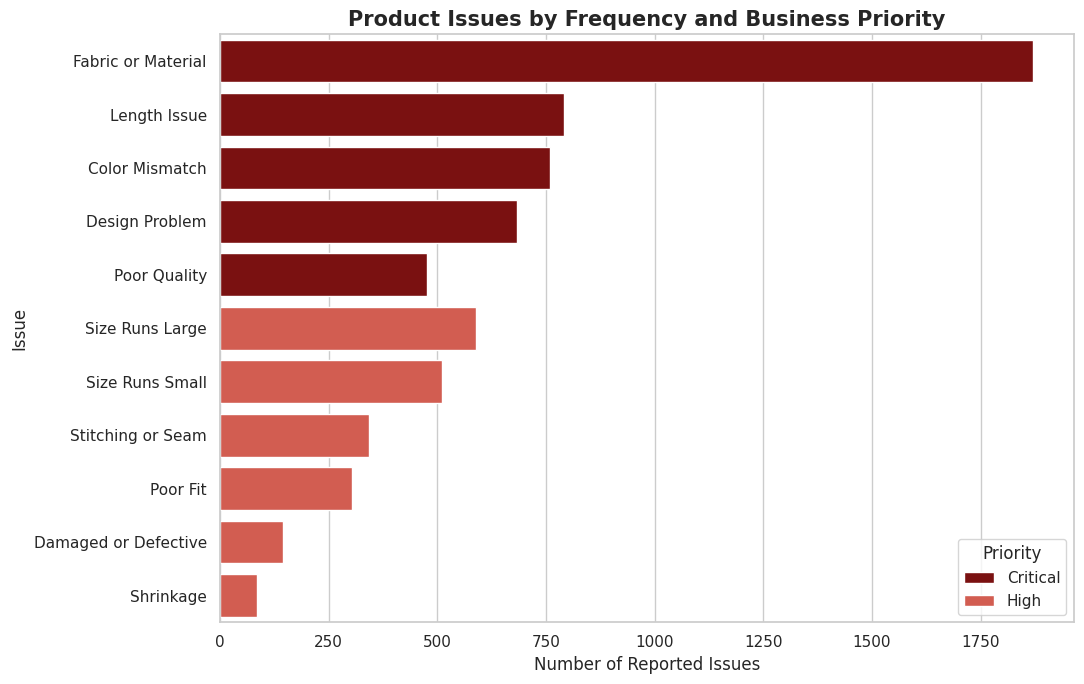

In [80]:
priority_colors = {
    "Critical": "#8B0000",
    "High": "#E74C3C",
    "Medium": "#F39C12",
    "Low": "#2ECC71"
}

plt.figure(figsize=(11, 7))

sns.barplot(
    data=issue_summary,
    x="Issue_Count",
    y="Issue",
    hue="Priority",
    palette=priority_colors,
    dodge=False
)

plt.title(
    "Product Issues by Frequency and Business Priority",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Number of Reported Issues")
plt.ylabel("Issue")
plt.legend(title="Priority")
plt.tight_layout()
plt.show()

###  Create the final action plan

In [81]:
final_action_plan = issue_summary[
    [
        "Issue",
        "Issue_Count",
        "Affected_Products",
        "Average_Rating",
        "Recommendation_Rate",
        "Priority",
        "Suggested Timeline",
        "Responsible Team",
        "Recommended Action",
        "KPI"
    ]
].copy()

final_action_plan = final_action_plan.rename(
    columns={
        "Issue_Count": "Number of Reports",
        "Affected_Products": "Number of Affected Products",
        "Average_Rating": "Average Rating",
        "Recommendation_Rate": "Recommendation Rate (%)"
    }
)

display(final_action_plan.round(2))

,Issue,Number of Reports,Number of Affected Products,Average Rating,Recommendation Rate (%),Priority,Suggested Timeline,Responsible Team,Recommended Action,KPI
0,Fabric or Material,1871,331,2.40,8.55,Critical,Immediate: 0–7 days,Sourcing and Quality Assurance,"Review fabric specifications, test comfort and...",Material complaint rate and average product ra...
1,Length Issue,791,226,2.58,12.90,Critical,Immediate: 0–7 days,Merchandising and E-commerce Content,"Display exact garment lengths and add petite, ...",Length-related complaint and return rate
2,Color Mismatch,758,215,2.54,11.74,Critical,Immediate: 0–7 days,E-commerce Content and Photography,Update product photography under consistent li...,Color-related complaint and return rate
3,Design Problem,683,210,2.43,9.22,Critical,Immediate: 0–7 days,Product Design,Review design elements reported by customers a...,Design complaint rate and average rating
4,Poor Quality,476,173,2.13,4.62,Critical,Immediate: 0–7 days,Quality Assurance and Supplier Management,"Inspect the product batch, review supplier qua...",Quality complaint rate and defective-product r...
5,Size Runs Large,588,195,2.58,15.31,High,Short term: 8–30 days,Merchandising and Product Sizing,"Verify garment measurements, update the size c...",Sizing complaint rate and size-related return ...
6,Size Runs Small,511,177,2.51,15.26,High,Short term: 8–30 days,Merchandising and Product Sizing,"Review garment measurements, update the size c...",Sizing complaint rate and size-related return ...
7,Stitching or Seam,343,132,2.37,11.66,High,Short term: 8–30 days,Quality Assurance and Supplier Management,"Inspect stitching standards, seam strength, zi...",Stitching complaint rate and defect return rate
8,Poor Fit,304,141,2.22,5.59,High,Short term: 8–30 days,Product Design and Merchandising,Review the garment pattern and fit specificati...,Fit complaint rate and recommendation rate
9,Damaged or Defective,145,83,2.14,5.52,High,Short term: 8–30 days,Quality Control and Warehouse Operations,"Quarantine the affected batch, inspect invento...",Defect rate and damaged-product return rate


### Export the Level 3 report

In [82]:
final_action_plan.to_csv(
    "level3_actionable_recommendations.csv",
    index=False
)

top_department_issues.to_csv(
    "level3_department_action_plan.csv",
    index=False
)

priority_products.to_csv(
    "level3_priority_products.csv",
    index=False
)

print("Level 3 reports saved successfully.")

Level 3 reports saved successfully.


### For downloading in Colab:

In [84]:
from google.colab import files

files.download(
    "level3_actionable_recommendations.csv"
)

files.download(
    "level3_department_action_plan.csv"
)

files.download(
    "level3_priority_products.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>